# 01 · CRY1–AN139 system preparation

## What this is

Ludovic's `System_Preparation/System_Prep.ipynb`, as **actually executed** by
`scripts/prepare_ludovic_native.py` — the headless version that the Slurm
pipeline calls. Same order, same tools, same intermediates. The two places where
it deliberately departs from the notebook are called out in §7 and are the only
departures.

## System

| Item | Value |
|---|---|
| Input | `CRY1AN139_HOLO.pdb` — combined experimental holo complex |
| Ligand | residue `LIG`, 34 heavy atoms in the input, **59 atoms** after protonation |
| Ligand charge | 0 (neutral within MOL2 rounding) |
| Protonation pH | 7.4 |
| Ligand FF | AM1-BCC charges, GAFF2 atom types (antechamber + parmchk2) |
| Protein FF | ff14SB, via PDBFixer then tLEaP |
| Water | TIP3P, `solvateOct` with 10 Å padding |
| Prepared output | 64,109 atoms · 18,800 waters · 1 Cl⁻ · 476 Cα |

## The one input rule

Use the **combined** `CRY1AN139_HOLO.pdb`. Do **not** take ligand chemistry from
`an139_ligh.sdf`: its coordinates match the crystal ligand, but its stored
tautomer/bond assignment differs from Ludovic's prepared ligand, and the
difference propagates silently into every downstream charge.

## Workflow

0. Configuration
1. Imports and helpers
2. Split the complex into ligand and protein
3. Ligand protonation (Open Babel, pH 7.4) and 2D check
4. Ligand GAFF2 / AM1-BCC parameterization
5. PDBFixer on the protein, and the chain-boundary problem
6. Merge, and the MOL2 atom-name fix
7. The two deliberate departures from the notebook
8. tLEaP solvation and neutralization
9. Acceptance checks on the prepared system
10. 3D visualization
11. Recap

---
## 0 · Configuration

**Edit this cell before running.** `RUN_PREPARATION = False` is the safe default:
the notebook then *audits* the retained reference preparation instead of
recomputing it. Set it to `True` to actually execute the toolchain into a fresh
directory.

In [1]:
from pathlib import Path

# ── Run mode ──────────────────────────────────────────────────────────────────
# False -> audit the retained reference preparation (fast, no AmberTools needed)
# True  -> execute obabel / antechamber / parmchk2 / PDBFixer / tLEaP for real
RUN_PREPARATION = False

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_1 = Path("/home/moshe/intern_projects/project_1")
LUDOVIC_ROOT = Path("/home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)")

# The required input. On the cluster this is
#   $HOME/cry/ludovic-workflow-gcmc/Other/MD/CRY1AN139_HOLO.pdb
INPUT_PDB = LUDOVIC_ROOT / "Other" / "MD" / "CRY1AN139_HOLO.pdb"

# Retained reference preparation, used when RUN_PREPARATION is False.
REFERENCE_PREP = PROJECT_1 / "preparation"

# Where a real run would write.
WORK_DIR = Path("prepared_from_notebook")

# ── Protocol parameters (match prepare_ludovic_native.py defaults) ────────────
PH = 7.4
LIGAND_CHARGE = 0
LIGAND_RESNAME = "LIG"
PDBFIXER_SEED = 0          # seeded so missing-atom placement is reproducible
SOLVATE_PADDING_A = 10.0
FF_PROTEIN = "ff14SB"
FF_WATER = "tip3p"

# ── Names, exactly as the pipeline writes them ─────────────────────────────────
PROTEIN_NAME = "CRY1"
LIGAND_NAME = "AN139"
COMPLEX_NAME = "CRY1AN139"

SOLVENT_RESNAMES = {"HOH", "WAT", "TIP", "SOL", "TIP3"}
SKIP_MERGE_RECORDS = {"END", "CONECT", "MASTER"}

PREP_DIR = WORK_DIR.resolve() if RUN_PREPARATION else REFERENCE_PREP
print(f"mode        : {'EXECUTE' if RUN_PREPARATION else 'AUDIT REFERENCE'}")
print(f"input PDB   : {INPUT_PDB}   (exists={INPUT_PDB.is_file()})")
print(f"prep dir    : {PREP_DIR}    (exists={PREP_DIR.is_dir()})")

mode        : AUDIT REFERENCE
input PDB   : /home/moshe/intern_projects/workflow-GCMC-Ludovic (after online tutorials)/Other/MD/CRY1AN139_HOLO.pdb   (exists=True)
prep dir    : /home/moshe/intern_projects/project_1/preparation    (exists=True)


---
## 1 · Imports and helpers

In [2]:
import shutil
import subprocess
from collections import Counter


def run(command, cwd, desc=""):
    """Run a shell command, echoing it the way the pipeline logs it."""
    if isinstance(command, str):
        command = command.split()
    print(f"\n▶ {desc or ' '.join(command)}")
    print(f"  $ {' '.join(command)}   (cwd={cwd})")
    if not RUN_PREPARATION:
        print("  [skipped — RUN_PREPARATION is False]")
        return None
    result = subprocess.run(command, cwd=str(cwd), check=True,
                            capture_output=True, text=True)
    tail = result.stdout.strip().splitlines()[-5:]
    for line in tail:
        print(f"  | {line}")
    return result


def pdb_atom_lines(path):
    return [l for l in Path(path).read_text().splitlines()
            if l[:6].strip() in ("ATOM", "HETATM")]


def tool_versions():
    """Record the chemistry toolchain — provenance belongs in the checkpoint."""
    out = {}
    for exe, args in (("obabel", ["-V"]), ("antechamber", ["-h"]),
                      ("parmchk2", ["-h"]), ("tleap", ["-h"])):
        path = shutil.which(exe)
        if not path:
            out[exe] = "NOT FOUND"
            continue
        try:
            r = subprocess.run([exe, *args], capture_output=True, text=True, timeout=30)
            first = (r.stdout or r.stderr).strip().splitlines()
            out[exe] = f"{path}  |  {first[0][:60] if first else '(no banner)'}"
        except Exception as exc:                                  # noqa: BLE001
            out[exe] = f"{path}  |  probe failed: {exc}"
    return out


if RUN_PREPARATION:
    WORK_DIR.mkdir(parents=True, exist_ok=True)

for exe, info in tool_versions().items():
    print(f"{exe:<12} {info}")

obabel       NOT FOUND
antechamber  NOT FOUND
parmchk2     NOT FOUND
tleap        NOT FOUND


---
## 2 · Split the complex into ligand and protein

Record-level split, not a chemistry operation. Solvent is dropped; the ligand is
everything with resname `LIG`; the protein keeps the structural header records
(`TER`, `CRYST1`, `SEQRES`, `SSBOND`, …) because PDBFixer needs them.

The split **raises** if no `LIG` residue is found rather than falling back to an
SDF — that fallback is the failure mode the input rule above exists to prevent.

In [3]:
# ── Ligand / protein extraction ───────────────────────────────────────────────
RETAINED_PROTEIN_RECORDS = {
    "TER", "END", "REMARK", "HEADER", "TITLE", "CRYST1", "SEQRES", "DBREF", "SSBOND",
}


def extract(source: Path, ligand_out: Path, protein_out: Path):
    ligand, protein = [], []
    for line in source.read_text().splitlines(keepends=True):
        record = line[:6].strip()
        resname = line[17:20].strip() if len(line) > 20 else ""
        if record in {"ATOM", "HETATM"}:
            if resname == LIGAND_RESNAME:
                ligand.append(line)
            elif resname not in SOLVENT_RESNAMES:
                protein.append(line)
        elif record in RETAINED_PROTEIN_RECORDS:
            protein.append(line)
    if not ligand:
        raise ValueError(
            f"No {LIGAND_RESNAME} residue in {source}. Ludovic's workflow requires the "
            "combined CRY1AN139_HOLO.pdb; do not infer ligand chemistry from SDF."
        )
    n_prot = sum(x.startswith(("ATOM", "HETATM")) for x in protein)
    if RUN_PREPARATION:
        ligand_out.write_text("".join(ligand) + "END\n")
        protein_out.write_text("".join(protein) + "END\n")
    print(f"  ligand atoms  : {len(ligand)}")
    print(f"  protein atoms : {n_prot}")
    return len(ligand), n_prot


LIGAND_RAW = PREP_DIR / f"{LIGAND_NAME}_raw.pdb"
PROTEIN_RAW = PREP_DIR / f"{PROTEIN_NAME}_raw.pdb"

if INPUT_PDB.is_file():
    n_lig_in, n_prot_in = extract(INPUT_PDB, LIGAND_RAW, PROTEIN_RAW)
    print(f"\n  the crystal ligand has {n_lig_in} heavy atoms "
          f"(34 for this input; hydrogens are added in §3)")
else:
    print(f"  input PDB absent: {INPUT_PDB}")
    print("  falling back to the retained raw split for the audit path")
    if LIGAND_RAW.is_file():
        print(f"  ligand atoms  : {len(pdb_atom_lines(LIGAND_RAW))}")
        print(f"  protein atoms : {len(pdb_atom_lines(PROTEIN_RAW))}")

  ligand atoms  : 34
  protein atoms : 3845

  the crystal ligand has 34 heavy atoms (34 for this input; hydrogens are added in §3)


---
## 3 · Ligand protonation

### 3a · Open Babel at pH 7.4, with Gasteiger charges

The Gasteiger charges are Open Babel's, and they are **not** the charges used in
the simulation — those come from antechamber's AM1-BCC in §4. Open Babel is here
only to add hydrogens at the requested pH.

In [4]:
LIGAND_PROTONATED_LUDOVIC = PREP_DIR / f"{LIGAND_NAME}_protonated_ludovic_names.pdb"
LIGAND_PROTONATED = PREP_DIR / f"{LIGAND_NAME}_protonated.pdb"
LIGAND_SDF = PREP_DIR / f"{LIGAND_NAME}_protonated.sdf"

run(["obabel", LIGAND_RAW.name, "-O", LIGAND_PROTONATED_LUDOVIC.name,
     "-p", str(PH), "--partialcharge", "gasteiger"],
    PREP_DIR, f"obabel: add H at pH {PH} + Gasteiger charges")

if LIGAND_PROTONATED_LUDOVIC.is_file():
    names = [l[12:16].strip() for l in pdb_atom_lines(LIGAND_PROTONATED_LUDOVIC)]
    dup = {n: c for n, c in Counter(names).items() if c > 1}
    print(f"\n  protonated ligand atoms : {len(names)}")
    print(f"  DUPLICATED atom names   : {dup}")
    print("  ^ this is departure #2 in §7 — tLEaP cannot map these unambiguously")


▶ obabel: add H at pH 7.4 + Gasteiger charges
  $ obabel AN139_raw.pdb -O AN139_protonated_ludovic_names.pdb -p 7.4 --partialcharge gasteiger   (cwd=/home/moshe/intern_projects/project_1/preparation)
  [skipped — RUN_PREPARATION is False]

  protonated ligand atoms : 59
  DUPLICATED atom names   : {'H': 25}
  ^ this is departure #2 in §7 — tLEaP cannot map these unambiguously


### 3b · Make duplicated ligand atom names unique

Open Babel emits several hydrogens with the same PDB atom name. tLEaP then has an
ambiguous coordinate-to-parameter mapping for those atoms: it does not error, it
just picks one. Renaming them (`H` → `H1`, `H2`, …) before tLEaP removes the
ambiguity and changes nothing chemically.

In [5]:
def unique_atom_names(input_pdb: Path, output_pdb: Path):
    """Suffix duplicated PDB atom names so tLeap's mapping is unambiguous."""
    lines = input_pdb.read_text().splitlines(keepends=True)
    names = [l[12:16].strip() for l in lines if l.startswith(("ATOM", "HETATM"))]
    totals = Counter(names)
    seen, result = Counter(), []
    for line in lines:
        if line.startswith(("ATOM", "HETATM")):
            name = line[12:16].strip()
            if totals[name] > 1:
                seen[name] += 1
                name = f"{name}{seen[name]}"
                if len(name) > 4:
                    raise ValueError(f"Cannot represent unique PDB atom name {name}")
                line = line[:12] + f"{name:>4}" + line[16:]
        result.append(line)
    if RUN_PREPARATION:
        output_pdb.write_text("".join(result))
    duplicates = {n: c for n, c in totals.items() if c > 1}
    print(f"  renamed groups: {duplicates}")
    return duplicates


if LIGAND_PROTONATED_LUDOVIC.is_file():
    unique_atom_names(LIGAND_PROTONATED_LUDOVIC, LIGAND_PROTONATED)

if LIGAND_PROTONATED.is_file():
    names = [l[12:16].strip() for l in pdb_atom_lines(LIGAND_PROTONATED)]
    still_dup = {n: c for n, c in Counter(names).items() if c > 1}
    print(f"\n  final ligand atoms      : {len(names)}")
    print(f"  remaining duplicates    : {still_dup or 'none'}")
    assert not still_dup, "ligand atom names must be unique before tLeap"

run(["obabel", LIGAND_PROTONATED.name, "-O", LIGAND_SDF.name],
    PREP_DIR, "obabel: PDB -> SDF for antechamber")

  renamed groups: {'H': 25}

  final ligand atoms      : 59
  remaining duplicates    : none

▶ obabel: PDB -> SDF for antechamber
  $ obabel AN139_protonated.pdb -O AN139_protonated.sdf   (cwd=/home/moshe/intern_projects/project_1/preparation)
  [skipped — RUN_PREPARATION is False]


### 3c · Ligand 2D depiction

Sanity check on the tautomer/bond assignment that Open Babel produced. This is
the object whose chemistry must not be swapped for `an139_ligh.sdf`.

heavy atoms : 34
formal charge: 0
SMILES      : Cc1ccc(-n2nc3c(c2NC(=O)c2ccc(C)c(C)c2)CN(C(=O)CC(F)(F)F)C3)c(C)c1


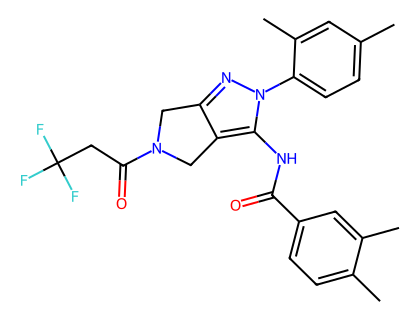

In [6]:
try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, Draw
    from IPython.display import display

    src = LIGAND_PROTONATED if LIGAND_PROTONATED.is_file() else None
    if src is None:
        print("no protonated ligand PDB available to depict")
    else:
        mol = Chem.MolFromPDBFile(str(src), removeHs=True, sanitize=True)
        if mol is None:
            print("RDKit could not sanitize the protonated ligand PDB")
        else:
            smiles = Chem.MolToSmiles(mol)
            flat = Chem.MolFromSmiles(smiles)
            AllChem.Compute2DCoords(flat)
            print(f"heavy atoms : {mol.GetNumAtoms()}")
            print(f"formal charge: {Chem.GetFormalCharge(mol)}")
            print(f"SMILES      : {smiles}")
            display(Draw.MolToImage(flat, size=(420, 320)))
except ImportError:
    print("rdkit not available in this kernel — skipping the 2D depiction")

---
## 4 · Ligand GAFF2 / AM1-BCC parameterization

`antechamber` is called **twice** on the same SDF with the same options:

- once with `-fo mol2` → the MOL2 that tLEaP loads, and
- once with `-fo prepi` → the PREPI that Ludovic's notebook produced for GRAND's
  ligand-XML route.

Loch never reads the PREPI. It is retained anyway, because this is a
reproduction of the notebook and a missing intermediate is a divergence someone
will eventually have to explain.

`parmchk2` then fills the missing GAFF2 terms into an `frcmod`, and a small tLEaP
script writes the **standalone ligand topology**. The solvated system does not
consume that either; the parity tests and batch benchmarks do.

In [7]:
LIGAND_MOL2 = PREP_DIR / f"{LIGAND_NAME}_protonated.mol2"
LIGAND_PREPI = PREP_DIR / f"{LIGAND_NAME}_protonated.prepi"
LIGAND_FRCMOD = PREP_DIR / f"{LIGAND_NAME}_protonated.frcmod"
LIGAND_PRMTOP = PREP_DIR / f"{LIGAND_NAME}_protonated.prmtop"
LIGAND_INPCRD = PREP_DIR / f"{LIGAND_NAME}_protonated.inpcrd"

antechamber_common = [
    "-i", LIGAND_SDF.name, "-fi", "sdf",
    "-c", "bcc",                       # AM1-BCC charges
    "-nc", str(LIGAND_CHARGE),         # requested net charge
    "-rn", LIGAND_RESNAME,
    "-at", "gaff2",                    # GAFF2 atom types
]

run(["antechamber", *antechamber_common, "-o", LIGAND_MOL2.name, "-fo", "mol2"],
    PREP_DIR, "antechamber: AM1-BCC / GAFF2 -> mol2")
run(["antechamber", *antechamber_common, "-o", LIGAND_PREPI.name, "-fo", "prepi"],
    PREP_DIR, "antechamber: second AM1-BCC pass -> prepi (notebook parity)")
run(["parmchk2", "-i", LIGAND_MOL2.name, "-f", "mol2", "-o", LIGAND_FRCMOD.name],
    PREP_DIR, "parmchk2: missing GAFF2 parameters")

# Standalone ligand topology, exactly as prepare_ligand.sh built it.
LIGAND_LEAP_IN = PREP_DIR / "ligand.in"
ligand_leap_script = (
    "source leaprc.gaff2\n"
    f"LIG = loadmol2 {LIGAND_MOL2.name}\n"
    f"loadamberparams {LIGAND_FRCMOD.name}\n"
    f"saveamberparm LIG {LIGAND_PRMTOP.name} {LIGAND_INPCRD.name}\n"
    "quit\n"
)
print("\n── ligand.in ──")
print(ligand_leap_script)
if RUN_PREPARATION:
    LIGAND_LEAP_IN.write_text(ligand_leap_script)
run(["tleap", "-f", LIGAND_LEAP_IN.name], PREP_DIR, "tleap: standalone ligand topology")


▶ antechamber: AM1-BCC / GAFF2 -> mol2
  $ antechamber -i AN139_protonated.sdf -fi sdf -c bcc -nc 0 -rn LIG -at gaff2 -o AN139_protonated.mol2 -fo mol2   (cwd=/home/moshe/intern_projects/project_1/preparation)
  [skipped — RUN_PREPARATION is False]

▶ antechamber: second AM1-BCC pass -> prepi (notebook parity)
  $ antechamber -i AN139_protonated.sdf -fi sdf -c bcc -nc 0 -rn LIG -at gaff2 -o AN139_protonated.prepi -fo prepi   (cwd=/home/moshe/intern_projects/project_1/preparation)
  [skipped — RUN_PREPARATION is False]

▶ parmchk2: missing GAFF2 parameters
  $ parmchk2 -i AN139_protonated.mol2 -f mol2 -o AN139_protonated.frcmod   (cwd=/home/moshe/intern_projects/project_1/preparation)
  [skipped — RUN_PREPARATION is False]

── ligand.in ──
source leaprc.gaff2
LIG = loadmol2 AN139_protonated.mol2
loadamberparams AN139_protonated.frcmod
saveamberparm LIG AN139_protonated.prmtop AN139_protonated.inpcrd
quit


▶ tleap: standalone ligand topology
  $ tleap -f ligand.in   (cwd=/home/moshe/in

In [8]:
# ── Acceptance checks on the ligand parameterization ─────────────────────────
# Two markers matter, and they are the ones the checkpoint audit requires:
#   1. SQM must report "Calculation Completed" — AM1 actually converged.
#   2. The MOL2 net charge must be near-integral and equal to what was requested.

def sqm_completed(prep_dir: Path) -> bool:
    for name in ("sqm.out", "ANTECHAMBER_AM1BCC.AC"):
        p = prep_dir / name
        if p.is_file() and "Calculation Completed" in p.read_text(errors="ignore"):
            return True
    # antechamber leaves the marker in its own log on some versions
    for p in prep_dir.glob("*.out"):
        if "Calculation Completed" in p.read_text(errors="ignore"):
            return True
    return False


def mol2_net_charge(mol2: Path) -> float:
    total, in_atoms = 0.0, False
    for line in mol2.read_text().splitlines():
        if line.startswith("@<TRIPOS>ATOM"):
            in_atoms = True
            continue
        if in_atoms and line.startswith("@<TRIPOS>"):
            break
        if in_atoms and line.strip():
            total += float(line.split()[-1])
    return total


if LIGAND_MOL2.is_file():
    q = mol2_net_charge(LIGAND_MOL2)
    atoms, in_atoms = 0, False
    for line in LIGAND_MOL2.read_text().splitlines():
        if line.startswith("@<TRIPOS>ATOM"):
            in_atoms = True
            continue
        if in_atoms and line.startswith("@<TRIPOS>"):
            break
        if in_atoms and line.strip():
            atoms += 1
    print(f"  MOL2 atoms        : {atoms}")
    print(f"  MOL2 net charge   : {q:+.6f}   (requested {LIGAND_CHARGE:+d})")
    print(f"  near-integral     : {abs(q - LIGAND_CHARGE) < 0.01}")
    print(f"  SQM completed     : {sqm_completed(PREP_DIR)}")
    assert abs(q - LIGAND_CHARGE) < 0.01, "AM1-BCC charge does not match the request"
    assert atoms == 59, f"expected 59 ligand atoms for this input, got {atoms}"
else:
    print(f"  MOL2 absent: {LIGAND_MOL2}")

  MOL2 atoms        : 59
  MOL2 net charge   : +0.000001   (requested +0)
  near-integral     : True
  SQM completed     : True


---
## 5 · PDBFixer on the protein

Standard PDBFixer sequence, with one addition: **both** the missing-atom
placement and the hydrogen placement are seeded. `addMissingAtoms(seed=...)` is
PDBFixer's own knob; `addMissingHydrogens` goes through OpenMM's `Modeller`,
which draws from Python's global `random`, so `random.seed()` has to be set too.
Without both, the same input gives a slightly different protein every run — and
with them, the reference preparation reproduces Ludovic's retained count of
**18,801** solvent residues.

In [9]:
PROTEIN_FIXED = PREP_DIR / f"{PROTEIN_NAME}_fixed.pdb"

pdbfixer_recipe = "\n".join([
    "import random",
    "from pdbfixer import PDBFixer",
    "from openmm.app import PDBFile",
    "",
    f'fixer = PDBFixer(filename="{PROTEIN_RAW.name}")',
    "fixer.findMissingResidues()          # 1/5",
    "fixer.findNonstandardResidues()      # 2/5",
    "fixer.replaceNonstandardResidues()",
    "fixer.removeHeterogens(keepWater=False)",
    "fixer.findMissingAtoms()             # 3/5",
    f"fixer.addMissingAtoms(seed={PDBFIXER_SEED})",
    "",
    "# 4/5 - OpenMM Modeller uses Python's global random for initial H placement,",
    "#       so PDBFixer's own seed is not sufficient on its own.",
    f"random.seed({PDBFIXER_SEED})",
    f"fixer.addMissingHydrogens({PH})      # 5/5",
    "",
    f'with open("{PROTEIN_FIXED.name}", "w") as fh:',
    "    PDBFile.writeFile(fixer.topology, fixer.positions, fh)",
])
print("── PDBFixer stage, as executed ──")
print(pdbfixer_recipe)

if RUN_PREPARATION:
    import random
    from pdbfixer import PDBFixer
    from openmm.app import PDBFile

    fixer = PDBFixer(filename=str(PROTEIN_RAW))
    print("  1/5 → missing residues")
    fixer.findMissingResidues()
    print("  2/5 → nonstandard residues")
    fixer.findNonstandardResidues()
    fixer.replaceNonstandardResidues()
    fixer.removeHeterogens(keepWater=False)
    print("  3/5 → missing atoms")
    fixer.findMissingAtoms()
    fixer.addMissingAtoms(seed=PDBFIXER_SEED)
    print("  4/5 → seeding global RNG for hydrogen placement")
    random.seed(PDBFIXER_SEED)
    print(f"  5/5 → missing hydrogens at pH {PH}")
    fixer.addMissingHydrogens(PH)
    with PROTEIN_FIXED.open("w") as fh:
        PDBFile.writeFile(fixer.topology, fixer.positions, fh)

if PROTEIN_FIXED.is_file():
    print(f"\n  fixed protein atoms: {len(pdb_atom_lines(PROTEIN_FIXED))}")

── PDBFixer stage, as executed ──
import random
from pdbfixer import PDBFixer
from openmm.app import PDBFile

fixer = PDBFixer(filename="CRY1_raw.pdb")
fixer.findMissingResidues()          # 1/5
fixer.findNonstandardResidues()      # 2/5
fixer.replaceNonstandardResidues()
fixer.removeHeterogens(keepWater=False)
fixer.findMissingAtoms()             # 3/5
fixer.addMissingAtoms(seed=0)

# 4/5 - OpenMM Modeller uses Python's global random for initial H placement,
#       so PDBFixer's own seed is not sufficient on its own.
random.seed(0)
fixer.addMissingHydrogens(7.4)      # 5/5

with open("CRY1_fixed.pdb", "w") as fh:
    PDBFile.writeFile(fixer.topology, fixer.positions, fh)

  fixed protein atoms: 7647


### 5b · The chain boundary that PDBFixer does not always keep

This input has a genuine chain break between LYS 220 and ALA 221. PDBFixer
signals it by leaving two backbone `H` atoms on LYS 220 and three N-terminal
hydrogens (`H`, `H2`, `H3`) on ALA 221 — but it does not reliably emit a `TER`
record there, and neither does Open Babel.

Stripping the protein hydrogens (§7) therefore destroys the only remaining
evidence of the boundary, and tLEaP then builds one continuous chain across it.
The pipeline handles this in two steps: prefer an internal `TER` if PDBFixer kept
one, and otherwise **detect the boundary from the terminal-hydrogen pattern
before the hydrogens are deleted**, then restore the `TER` afterwards. If neither
is found it raises rather than guessing.

In [10]:
def residue_atom_names(path: Path):
    order, atoms = [], {}
    for line in Path(path).read_text().splitlines():
        if not line.startswith(("ATOM", "HETATM")):
            continue
        key = (line[21], line[22:26].strip(), line[26])
        if key not in atoms:
            order.append(key)
            atoms[key] = []
        atoms[key].append(line[12:16].strip())
    return order, atoms


def pdb_ter_boundaries(path: Path):
    """Internal TER positions, expressed as the preceding residue index."""
    residue_index, last_key, ter_after = 0, None, []
    for line in Path(path).read_text().splitlines():
        if line.startswith(("ATOM", "HETATM")):
            key = (line[21], line[22:26].strip(), line[26])
            if key != last_key:
                residue_index += 1
                last_key = key
        elif line.startswith("TER") and residue_index:
            ter_after.append(residue_index)
    return [i for i in ter_after if i < residue_index]


def terminal_boundaries(path: Path):
    """Chain boundaries implied by adjacent C-terminal / N-terminal hydrogens."""
    order, atoms = residue_atom_names(path)
    found = []
    for index, (prev, cur) in enumerate(zip(order, order[1:]), start=1):
        p, c = Counter(atoms[prev]), Counter(atoms[cur])
        prev_terminal = p["H"] >= 2
        cur_n_terminal = (
            sum(c[n] for n in ("H", "H1", "H2", "H3")) >= 3
            and c["H2"] >= 1 and c["H3"] >= 1
        )
        if prev_terminal and cur_n_terminal:
            found.append(index)
            print(f"  boundary after residue {index}: {prev} -> {cur}")
    return found


BOUNDARIES = []
if PROTEIN_FIXED.is_file():
    BOUNDARIES = pdb_ter_boundaries(PROTEIN_FIXED)
    if BOUNDARIES:
        print(f"  PDBFixer kept internal TER after residue(s) {BOUNDARIES}")
    else:
        print("  no internal TER — detecting from terminal hydrogens:")
        BOUNDARIES = terminal_boundaries(PROTEIN_FIXED)
    if not BOUNDARIES:
        print("  !! neither an internal TER nor a terminal-H boundary was found.")
        print("     prepare_ludovic_native.py raises here rather than continuing.")
else:
    print(f"  {PROTEIN_FIXED} absent — cannot evaluate boundaries")

  PDBFixer kept internal TER after residue(s) [220]


---
## 6 · Merge, and the MOL2 atom-name fix

Two merged complexes are written, and both are kept:

| File | Contents | Purpose |
|---|---|---|
| `CRY1AN139_ready.pdb` | fixed protein **with** hydrogens + protonated ligand | visualization / checkpoint |
| `CRY1AN139_ready_nohyd.pdb` | protein **without** hydrogens + protonated ligand | the tLEaP input |

Separately: antechamber reorders and renames MOL2 atoms relative to the ligand
PDB. tLEaP matches the `loadmol2` template to `loadpdb` coordinates **by atom
name**, so the MOL2 names have to be rewritten back into PDB order first. Getting
this wrong assigns the wrong GAFF2 type and charge to the wrong nucleus, and
nothing errors.

In [11]:
def merge_pdbs(paths, output: Path):
    lines = []
    for path in paths:
        for line in Path(path).read_text().splitlines(keepends=True):
            if line[:6].strip() not in SKIP_MERGE_RECORDS:
                lines.append(line)
        if lines and not lines[-1].startswith("TER"):
            lines.append("TER\n")
    lines.append("END\n")
    if RUN_PREPARATION:
        Path(output).write_text("".join(lines))
    return sum(1 for l in lines if l.startswith(("ATOM", "HETATM")))


def fix_mol2_names(mol2: Path, ligand_pdb: Path, output: Path):
    """Rewrite MOL2 atom names into the reference PDB's atom order."""
    pdb_names = [l[12:16].strip() for l in pdb_atom_lines(ligand_pdb)]
    result, atom_index, in_atoms = [], 0, False
    for line in Path(mol2).read_text().splitlines():
        if line == "@<TRIPOS>ATOM":
            in_atoms = True
            result.append(line)
            continue
        if in_atoms and line.startswith("@<TRIPOS>"):
            in_atoms = False
        if in_atoms and line.strip():
            parts = line.split()
            if atom_index >= len(pdb_names):
                raise RuntimeError("MOL2 has more atoms than the ligand PDB")
            line = line.replace(parts[1], pdb_names[atom_index], 1)
            atom_index += 1
        result.append(line)
    if atom_index != len(pdb_names):
        raise RuntimeError(f"Renamed {atom_index} MOL2 atoms for {len(pdb_names)} PDB atoms")
    if RUN_PREPARATION:
        Path(output).write_text("\n".join(result) + "\n")
    return atom_index


COMPLEX_READY = PREP_DIR / f"{COMPLEX_NAME}_ready.pdb"
COMPLEX_NOHYD = PREP_DIR / f"{COMPLEX_NAME}_ready_nohyd.pdb"
LIGAND_MOL2_FIXED = PREP_DIR / f"{LIGAND_NAME}_protonated_fixed.mol2"

for path, label in ((COMPLEX_READY, "with protein H"),
                    (COMPLEX_NOHYD, "protein H removed")):
    if path.is_file():
        print(f"  {path.name:<32} {len(pdb_atom_lines(path)):>7} atoms   ({label})")

if LIGAND_MOL2.is_file() and LIGAND_PROTONATED.is_file():
    n = fix_mol2_names(LIGAND_MOL2, LIGAND_PROTONATED, LIGAND_MOL2_FIXED)
    print(f"\n  MOL2 atom names rewritten into PDB order: {n} atoms")
if LIGAND_MOL2_FIXED.is_file():
    ref = [l[12:16].strip() for l in pdb_atom_lines(LIGAND_PROTONATED)]
    got, in_atoms = [], False
    for line in LIGAND_MOL2_FIXED.read_text().splitlines():
        if line.startswith("@<TRIPOS>ATOM"):
            in_atoms = True
            continue
        if in_atoms and line.startswith("@<TRIPOS>"):
            break
        if in_atoms and line.strip():
            got.append(line.split()[1])
    print(f"  MOL2 order == PDB order : {got == ref}")
    assert got == ref, "MOL2/PDB atom-name order mismatch — tLeap would mis-map"

  CRY1AN139_ready.pdb                 7706 atoms   (with protein H)
  CRY1AN139_ready_nohyd.pdb           3906 atoms   (protein H removed)

  MOL2 atom names rewritten into PDB order: 59 atoms
  MOL2 order == PDB order : True


---
## 7 · The two deliberate departures from the notebook

These are the only two, and both are safety changes rather than protocol
changes. Anything else that differs is a bug.

### Departure 1 — protein hydrogens are removed with OpenMM, not `obabel -d`

The notebook runs `obabel <fixed> -O <nohyd> -d`. On this input Open Babel's bond
perception sometimes leaves **unbound hydrogens** behind, which tLEaP then treats
as extra atoms. OpenMM's `Modeller.delete()` over `element.symbol == "H"` is
chemically equivalent and guarantees that every protein hydrogen is gone.

The cost is that OpenMM's writer does not carry the internal `TER` — hence §5b.

### Departure 2 — duplicated ligand hydrogen names are made unique before tLEaP

Covered in §3b. Without it tLEaP's coordinate-to-parameter mapping for those
hydrogens is ambiguous, and it resolves the ambiguity silently.

In [12]:
# ── Departure 1, as executed ─────────────────────────────────────────────────
PROTEIN_NOH_OPENMM = PREP_DIR / f"{PROTEIN_NAME}_fixed_nohyd_openmm.pdb"
PROTEIN_NOH = PREP_DIR / f"{PROTEIN_NAME}_fixed_nohyd.pdb"

print("notebook          : obabel CRY1_fixed.pdb -O CRY1_fixed_nohyd.pdb -d")
print("pipeline instead  : openmm.app.Modeller.delete(H) -> *_nohyd_openmm.pdb")
print("                    then restore_boundaries() -> *_nohyd.pdb")

if RUN_PREPARATION:
    from openmm.app import Modeller, PDBFile

    pdb = PDBFile(str(PROTEIN_FIXED))
    modeller = Modeller(pdb.topology, pdb.positions)
    modeller.delete(a for a in modeller.topology.atoms()
                    if a.element is not None and a.element.symbol == "H")
    with PROTEIN_NOH_OPENMM.open("w") as fh:
        PDBFile.writeFile(modeller.topology, modeller.positions, fh, keepIds=True)


def restore_boundaries(input_pdb: Path, output_pdb: Path, after_residue_indices):
    boundaries = set(after_residue_indices)
    lines = Path(input_pdb).read_text().splitlines(keepends=True)
    result, last_key, residue_index = [], None, 0
    for line in lines:
        if line.startswith(("ATOM", "HETATM")):
            key = (line[21], line[22:26].strip(), line[26])
            if key != last_key:
                if (last_key is not None and residue_index in boundaries
                        and (not result or not result[-1].startswith("TER"))):
                    result.append("TER\n")
                residue_index += 1
                last_key = key
        result.append(line)
    if RUN_PREPARATION:
        Path(output_pdb).write_text("".join(result))
    return sum(1 for l in result if l.startswith("TER"))


if PROTEIN_NOH_OPENMM.is_file():
    if PROTEIN_FIXED.is_file():
        print(f"\n  protein atoms with H          : {len(pdb_atom_lines(PROTEIN_FIXED))}")
    print(f"  protein atoms after H removal : {len(pdb_atom_lines(PROTEIN_NOH_OPENMM))}")
    n_ter = restore_boundaries(PROTEIN_NOH_OPENMM, PROTEIN_NOH, BOUNDARIES)
    print(f"  TER records after restore     : {n_ter}")
if PROTEIN_NOH.is_file():
    print(f"  internal TER boundaries       : {pdb_ter_boundaries(PROTEIN_NOH)}")

notebook          : obabel CRY1_fixed.pdb -O CRY1_fixed_nohyd.pdb -d
pipeline instead  : openmm.app.Modeller.delete(H) -> *_nohyd_openmm.pdb
                    then restore_boundaries() -> *_nohyd.pdb



  protein atoms with H          : 7647
  protein atoms after H removal : 3847
  TER records after restore     : 2
  internal TER boundaries       : [220]


---
## 8 · tLEaP solvation and neutralization

`addionsrand complex Na+ 0` is issued **first** and is expected to warn. The
unsolvated complex carries charge **+1**, so tLEaP refuses to add a same-sign
counter-ion; the following `Cl- 0` then neutralizes it. That warning in
`leap.log` is normal and must not be "fixed".

The chloride **replaces a water**, which is why the arithmetic comes out as
18,801 solvent residues added → 18,800 physical waters.

In [13]:
SOLVATED_PRMTOP = PREP_DIR / f"{COMPLEX_NAME}_solvated.prmtop"
SOLVATED_INPCRD = PREP_DIR / f"{COMPLEX_NAME}_solvated.inpcrd"
SOLVATED_PDB = PREP_DIR / f"{COMPLEX_NAME}_solvated.pdb"
SOLVATE_IN = PREP_DIR / "solvate.in"

solvate_script = f"""source leaprc.protein.{FF_PROTEIN}
source leaprc.gaff2
source leaprc.water.{FF_WATER}
loadamberparams {LIGAND_FRCMOD.name}
LIG = loadmol2 {LIGAND_MOL2_FIXED.name}
complex = loadpdb {COMPLEX_NOHYD.name}
solvateOct complex TIP3PBOX {SOLVATE_PADDING_A}
addionsrand complex Na+ 0
addionsrand complex Cl- 0
saveamberparm complex {SOLVATED_PRMTOP.name} {SOLVATED_INPCRD.name}
savepdb complex {SOLVATED_PDB.name}
quit
"""
print("── solvate.in ──")
print(solvate_script)
if RUN_PREPARATION:
    SOLVATE_IN.write_text(solvate_script)
run(["tleap", "-f", SOLVATE_IN.name], PREP_DIR, "tleap: solvate + neutralize")

── solvate.in ──
source leaprc.protein.ff14SB
source leaprc.gaff2
source leaprc.water.tip3p
loadamberparams AN139_protonated.frcmod
LIG = loadmol2 AN139_protonated_fixed.mol2
complex = loadpdb CRY1AN139_ready_nohyd.pdb
solvateOct complex TIP3PBOX 10.0
addionsrand complex Na+ 0
addionsrand complex Cl- 0
saveamberparm complex CRY1AN139_solvated.prmtop CRY1AN139_solvated.inpcrd
savepdb complex CRY1AN139_solvated.pdb
quit


▶ tleap: solvate + neutralize
  $ tleap -f solvate.in   (cwd=/home/moshe/intern_projects/project_1/preparation)
  [skipped — RUN_PREPARATION is False]


In [14]:
# ── Read the two things leap.log must say ────────────────────────────────────
leap_log = PREP_DIR / "leap.log"
if leap_log.is_file():
    text = leap_log.read_text(errors="ignore")
    added = [l.strip() for l in text.splitlines() if "Added" in l and "residues" in l]
    errors = [l.strip() for l in text.splitlines()
              if l.strip().startswith("Errors =") or "Errors =" in l]
    samesign = [l.strip() for l in text.splitlines()
                if "same" in l.lower() and "sign" in l.lower()]
    print("  solvent residues added :")
    for l in added:
        print(f"      {l}")
    print("  final error line       :")
    for l in errors[-1:]:
        print(f"      {l}")
    print(f"  expected same-sign warning present : {bool(samesign)}")
    for l in samesign[:2]:
        print(f"      {l[:100]}")
else:
    print(f"  leap.log absent: {leap_log}")

  solvent residues added :
      Added 18801 residues.
  final error line       :
      Exiting LEaP: Errors = 0; Warnings = 7; Notes = 1.
  expected same-sign warning present : True
      addIonsRand: 1st Ion & target unit have charges of the same sign:


---
## 9 · Acceptance checks on the prepared system

Level 1 of the four-level gate (the other three live in notebook 03). Reload the
AMBER pair independently — do not trust the in-memory object that wrote it.

In [15]:
# ── Independent reload of the prepared AMBER topology ────────────────────────
REFERENCE = {
    "atoms": 64109,
    "waters": 18800,
    "chloride": 1,
    "ligand_atoms": 59,
    "protein_ca": 476,
    "solvent_residues_added": 18801,
}

try:
    import parmed as pmd
except ImportError:
    pmd = None
    print("parmed not available in this kernel — skipping the topology audit")

if pmd is not None and SOLVATED_PRMTOP.is_file():
    top = pmd.load_file(str(SOLVATED_PRMTOP))
    names = Counter(r.name for r in top.residues)
    ligand = next((r for r in top.residues if r.name == LIGAND_RESNAME), None)
    ca = [a for a in top.atoms
          if a.name == "CA" and a.residue.name not in ("WAT", LIGAND_RESNAME)]

    # A three-site water with simultaneously zero charge AND zero LJ epsilon is a
    # leaked ghost. There must be none in a physical topology, at any stage.
    zero_interaction = [
        r for r in top.residues
        if r.name == "WAT" and len(r.atoms) == 3
        and all(abs(a.charge) < 1e-9 for a in r.atoms)
        and all(a.epsilon == 0.0 for a in r.atoms)
    ]

    observed = {
        "atoms": len(top.atoms),
        "waters": names.get("WAT", 0),
        "chloride": names.get("Cl-", 0),
        "ligand_atoms": len(ligand.atoms) if ligand else 0,
        "protein_ca": len(ca),
    }
    total_charge = sum(a.charge for a in top.atoms)

    W = 74

    def row(text):
        print("║ " + text.ljust(W - 1) + "║")

    print("╔" + "═" * W + "╗")
    row(f"{'PREPARED SYSTEM — independent reload':^{W - 1}}".rstrip())
    print("╠" + "═" * W + "╣")
    for key, want in REFERENCE.items():
        if key not in observed:
            continue
        got = observed[key]
        flag = "ok " if got == want else "!! "
        row(f"{flag}{key:<26}{got:>12,}   reference {want:>12,}")
    print("╟" + "─" * W + "╢")
    row(f"   {'total charge':<26}{total_charge:>+12.6f}")
    row(f"   {'zero-interaction waters':<26}{len(zero_interaction):>12}   must be 0")
    print("╚" + "═" * W + "╝")

    assert not zero_interaction, "prepared topology contains zero-interaction waters"
    assert abs(total_charge) < 1e-3, f"prepared system is not neutral: {total_charge}"
elif pmd is not None:
    print(f"  prepared topology absent: {SOLVATED_PRMTOP}")

╔══════════════════════════════════════════════════════════════════════════╗
║                   PREPARED SYSTEM — independent reload                   ║
╠══════════════════════════════════════════════════════════════════════════╣
║ ok atoms                           64,109   reference       64,109       ║
║ ok waters                          18,800   reference       18,800       ║
║ ok chloride                             1   reference            1       ║
║ ok ligand_atoms                        59   reference           59       ║
║ ok protein_ca                         476   reference          476       ║
╟──────────────────────────────────────────────────────────────────────────╢
║    total charge                 +0.000001                                ║
║    zero-interaction waters              0   must be 0                    ║
╚══════════════════════════════════════════════════════════════════════════╝


### 9b · The two long C–N bonds, and why they are left alone

tLEaP reports two unusually long C–N bonds in this system, at **10.563 Å** and
**17.240 Å**. They are **retained on purpose**: Ludovic's original system
contains them, and this pipeline's job is parity.

In the known-good run they relaxed to **1.301 Å** and **2.327 Å** by the UVT2
handoff. The second is still odd, but Ludovic's twelve deposited production
replicas span **2.308–2.372 Å** for the same distance, so it is an inherited
structural artefact of his system rather than a Loch failure.

Do not silently add a `TER`, delete the bond, or otherwise repair it inside the
parity workflow. If it should be corrected scientifically, that is a separately
named protocol variant.

In [16]:
# ── Locate the two long bonds and report their current length ────────────────
import math

if pmd is not None and SOLVATED_PRMTOP.is_file() and SOLVATED_INPCRD.is_file():
    sys_ = pmd.load_file(str(SOLVATED_PRMTOP), xyz=str(SOLVATED_INPCRD))
    long_bonds = []
    for b in sys_.bonds:
        a1, a2 = b.atom1, b.atom2
        elems = {a1.element_name, a2.element_name}
        if elems != {"C", "N"}:
            continue
        d = math.dist(
            (a1.xx, a1.xy, a1.xz),
            (a2.xx, a2.xy, a2.xz),
        )
        if d > 3.0:
            long_bonds.append((d, a1, a2))
    long_bonds.sort(reverse=True)
    print(f"  C-N bonds longer than 3 A in the PREPARED system: {len(long_bonds)}")
    for d, a1, a2 in long_bonds:
        print(f"      {d:7.3f} A   {a1.residue.name}{a1.residue.number}:{a1.name}"
              f"  -  {a2.residue.name}{a2.residue.number}:{a2.name}")
    print("""
  Reference: 10.563 A and 17.240 A at preparation;
             1.301 A and 2.327 A by the UVT2 handoff in the known-good run;
             Ludovic's 12 replicas span 2.308-2.372 A for the second.
""")

  C-N bonds longer than 3 A in the PREPARED system: 2
       17.240 A   LYS266:C  -  SER267:N
       10.563 A   PRO37:C  -  VAL38:N

  Reference: 10.563 A and 17.240 A at preparation;
             1.301 A and 2.327 A by the UVT2 handoff in the known-good run;
             Ludovic's 12 replicas span 2.308-2.372 A for the second.



---
## 10 · 3D visualization of the solvation stages

In [17]:
try:
    import py3Dmol

    LIGAND_SHELL_A = 8.0   # A: waters shown around the ligand in the solvated panel

    def solvation_shell_pdb(path, ligand_resname=LIGAND_RESNAME, radius=LIGAND_SHELL_A):
        """Solute + ions + only the waters within `radius` of the ligand.

        The full solvated box is 64,109 atoms. Handing all of it to py3Dmol embeds
        every coordinate in the notebook (9 MB for this system) and draws an opaque
        block of water that shows nothing. The solvation shell is both the
        informative view and three orders of magnitude smaller.
        """
        solute, waters = [], {}
        for line in Path(path).read_text().splitlines():
            if line[:6].strip() not in ("ATOM", "HETATM"):
                continue
            resname = line[17:20].strip()
            if resname in ("WAT", "HOH"):
                waters.setdefault(line[22:27], []).append(line)
            else:
                solute.append(line)
        ligand = [l for l in solute if l[17:20].strip() == ligand_resname]
        if not ligand:
            return "\n".join(solute) + "\nEND\n"
        centre = [
            sum(float(l[30 + 8 * k:38 + 8 * k]) for l in ligand) / len(ligand)
            for k in range(3)
        ]
        kept = []
        for residue in waters.values():
            for atom in residue:
                dx = float(atom[30:38]) - centre[0]
                dy = float(atom[38:46]) - centre[1]
                dz = float(atom[46:54]) - centre[2]
                if dx * dx + dy * dy + dz * dz <= radius * radius:
                    kept.extend(residue)
                    break
        return "\n".join(solute + kept) + "\nEND\n"

    panels = [
        ("Experimental holo input", INPUT_PDB, False),
        ("Complex before solvation", COMPLEX_NOHYD, False),
        (f"Solvated system — solute + waters within {LIGAND_SHELL_A:.0f} A of the ligand",
         SOLVATED_PDB, True),
    ]
    for title, path, show_water in panels:
        if not Path(path).is_file():
            print(f"{title}: file absent ({path})")
            continue
        text = solvation_shell_pdb(path) if show_water else Path(path).read_text()
        view = py3Dmol.view(width=760, height=420)
        view.addModel(text, "pdb")
        view.setStyle({"cartoon": {"color": "spectrum"}})
        view.addStyle({"resn": LIGAND_RESNAME},
                      {"stick": {"colorscheme": "greenCarbon", "radius": 0.18}})
        if show_water:
            view.addStyle({"resn": ["WAT", "HOH"]},
                          {"stick": {"radius": 0.05, "opacity": 0.55}})
            view.addStyle({"resn": ["Cl-", "CL"]},
                          {"sphere": {"radius": 0.6, "color": "green"}})
        view.zoomTo({"resn": LIGAND_RESNAME})
        n_atoms = sum(1 for l in text.splitlines() if l[:6].strip() in ("ATOM", "HETATM"))
        print(f"── {title} ── {n_atoms:,} atoms rendered")
        view.show()
except ImportError:
    print("py3Dmol not available in this kernel — skipping 3D views")

── Experimental holo input ── 4,196 atoms rendered


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

── Complex before solvation ── 3,906 atoms rendered


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

── Solvated system — solute + waters within 8 A of the ligand ── 7,718 atoms rendered


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---
## 11 · Recap

In [18]:
# ── What preparation must hand to Loch equilibration ─────────────────────────
CONTRACT = [
    f"{COMPLEX_NAME}_solvated.prmtop",
    f"{COMPLEX_NAME}_solvated.inpcrd",
]

print("STAGE CONTRACT — equilibration consumes exactly these two files")
print("─" * 72)
for name in CONTRACT:
    p = PREP_DIR / name
    size = f"{p.stat().st_size:,} bytes" if p.is_file() else "MISSING"
    print(f"  {name:<40} {size}")

print("""
RETAINED but NOT consumed by the solvated Loch run (notebook-parity artefacts):
  AN139_protonated.prepi        GRAND's ligand-XML route
  AN139_protonated.prmtop/.inpcrd   standalone ligand topology (parity tests,
                                    batch benchmarks, and prepare_fep.py)
  CRY1AN139_ready.pdb           pre-H-removal complex, visualization checkpoint

ONE-LINE INVOCATION (cluster, cry-loch-babel):

  python -u scripts/prepare_ludovic_native.py \\
      --input-pdb "$HOME/cry/ludovic-workflow-gcmc/Other/MD/CRY1AN139_HOLO.pdb" \\
      --output-dir <run>/preparation \\
      --ph 7.4 --ligand-charge 0 --pdbfixer-seed 0

  --reuse-ligand-parameters skips the two antechamber passes when
  AN139_protonated.{pdb,mol2,prepi} are already present and non-empty.
""")

STAGE CONTRACT — equilibration consumes exactly these two files
────────────────────────────────────────────────────────────────────────
  CRY1AN139_solvated.prmtop                12,334,962 bytes
  CRY1AN139_solvated.inpcrd                2,340,072 bytes

RETAINED but NOT consumed by the solvated Loch run (notebook-parity artefacts):
  AN139_protonated.prepi        GRAND's ligand-XML route
  AN139_protonated.prmtop/.inpcrd   standalone ligand topology (parity tests,
                                    batch benchmarks, and prepare_fep.py)
  CRY1AN139_ready.pdb           pre-H-removal complex, visualization checkpoint

ONE-LINE INVOCATION (cluster, cry-loch-babel):

  python -u scripts/prepare_ludovic_native.py \
      --input-pdb "$HOME/cry/ludovic-workflow-gcmc/Other/MD/CRY1AN139_HOLO.pdb" \
      --output-dir <run>/preparation \
      --ph 7.4 --ligand-charge 0 --pdbfixer-seed 0

  --reuse-ligand-parameters skips the two antechamber passes when
  AN139_protonated.{pdb,mol2,prepi} ar

### Notes

**Reproducibility is seeded, not guaranteed by construction.** `--pdbfixer-seed 0`
plus `random.seed(0)` is what makes the water count land on 18,801 again. Change
the seed and you get a valid but different system; that is a new replica, not a
reproduction.

**What is stochastic and what is not.** Solvent counts and ion placement are
reproducible under a fixed seed. Downstream, GCMC acceptance histories and water
counts are *not* reproducible in any useful sense, and no acceptance test should
be written against them. Test topology invariants, report counts and operation
order instead.

**Provenance to record in the checkpoint.** Hashes of the executed AmberTools
binaries, the force-field/data files they read, the exact commands, the inputs
and the logs — plus `ligand_charge`, `ligand_sha256` and `ligand_id`. The FEP
branch reads that signature directly (notebook 06), so it is not optional
bookkeeping.

**Next:** notebook 02 takes `CRY1AN139_solvated.{prmtop,inpcrd}` through
UVT1 → NPT → UVT2 → 10 ns production.